In [8]:
%autoreload 2

In [1]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 13})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_32668\1284024126.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__BOUT FINDER__

In [42]:
path = r'Z://cleo//Imaging//260425_overlap//fish11_2//'
#if imaging fish
fish = Gafftopsail(path, sequence  = 1, filelist = ['stimulus', 'eye'])
#if behavior rig fish
#fish = Coelacanth(path, filelist = ['taileye', 'stimulus'])

In [43]:
if type(fish) == Gafftopsail:
    pass
elif type(fish) == Coelacanth:
    fish.eye_df = fish.taileye_df
    fish.eye_df.columns = ['f0_x', 'f0_vx', 'f0_y', 'f0_vy', 'f0_theta', 'f0_vtheta',
           'f0_theta_00', 'f0_theta_01', 'f0_theta_02', 'f0_theta_03',
           'f0_theta_04', 'f0_theta_05', 'f0_theta_06', 'f0_theta_07',
           'f0_theta_08', 'f0_theta_09', 'f0_theta_10', 'f0_theta_11',
           'f0_pos_x_e0', 'f0_pos_y_e0', 'f0_dim_x_e0', 'f0_dim_y_e0', 'th_e0',
           'f0_pos_x_e1', 'f0_pos_y_e1', 'f0_dim_x_e1', 'f0_dim_y_e1', 'th_e1',
           'biggest_area', 't', 'real_time', 'real_time_s']

usual 2P setup


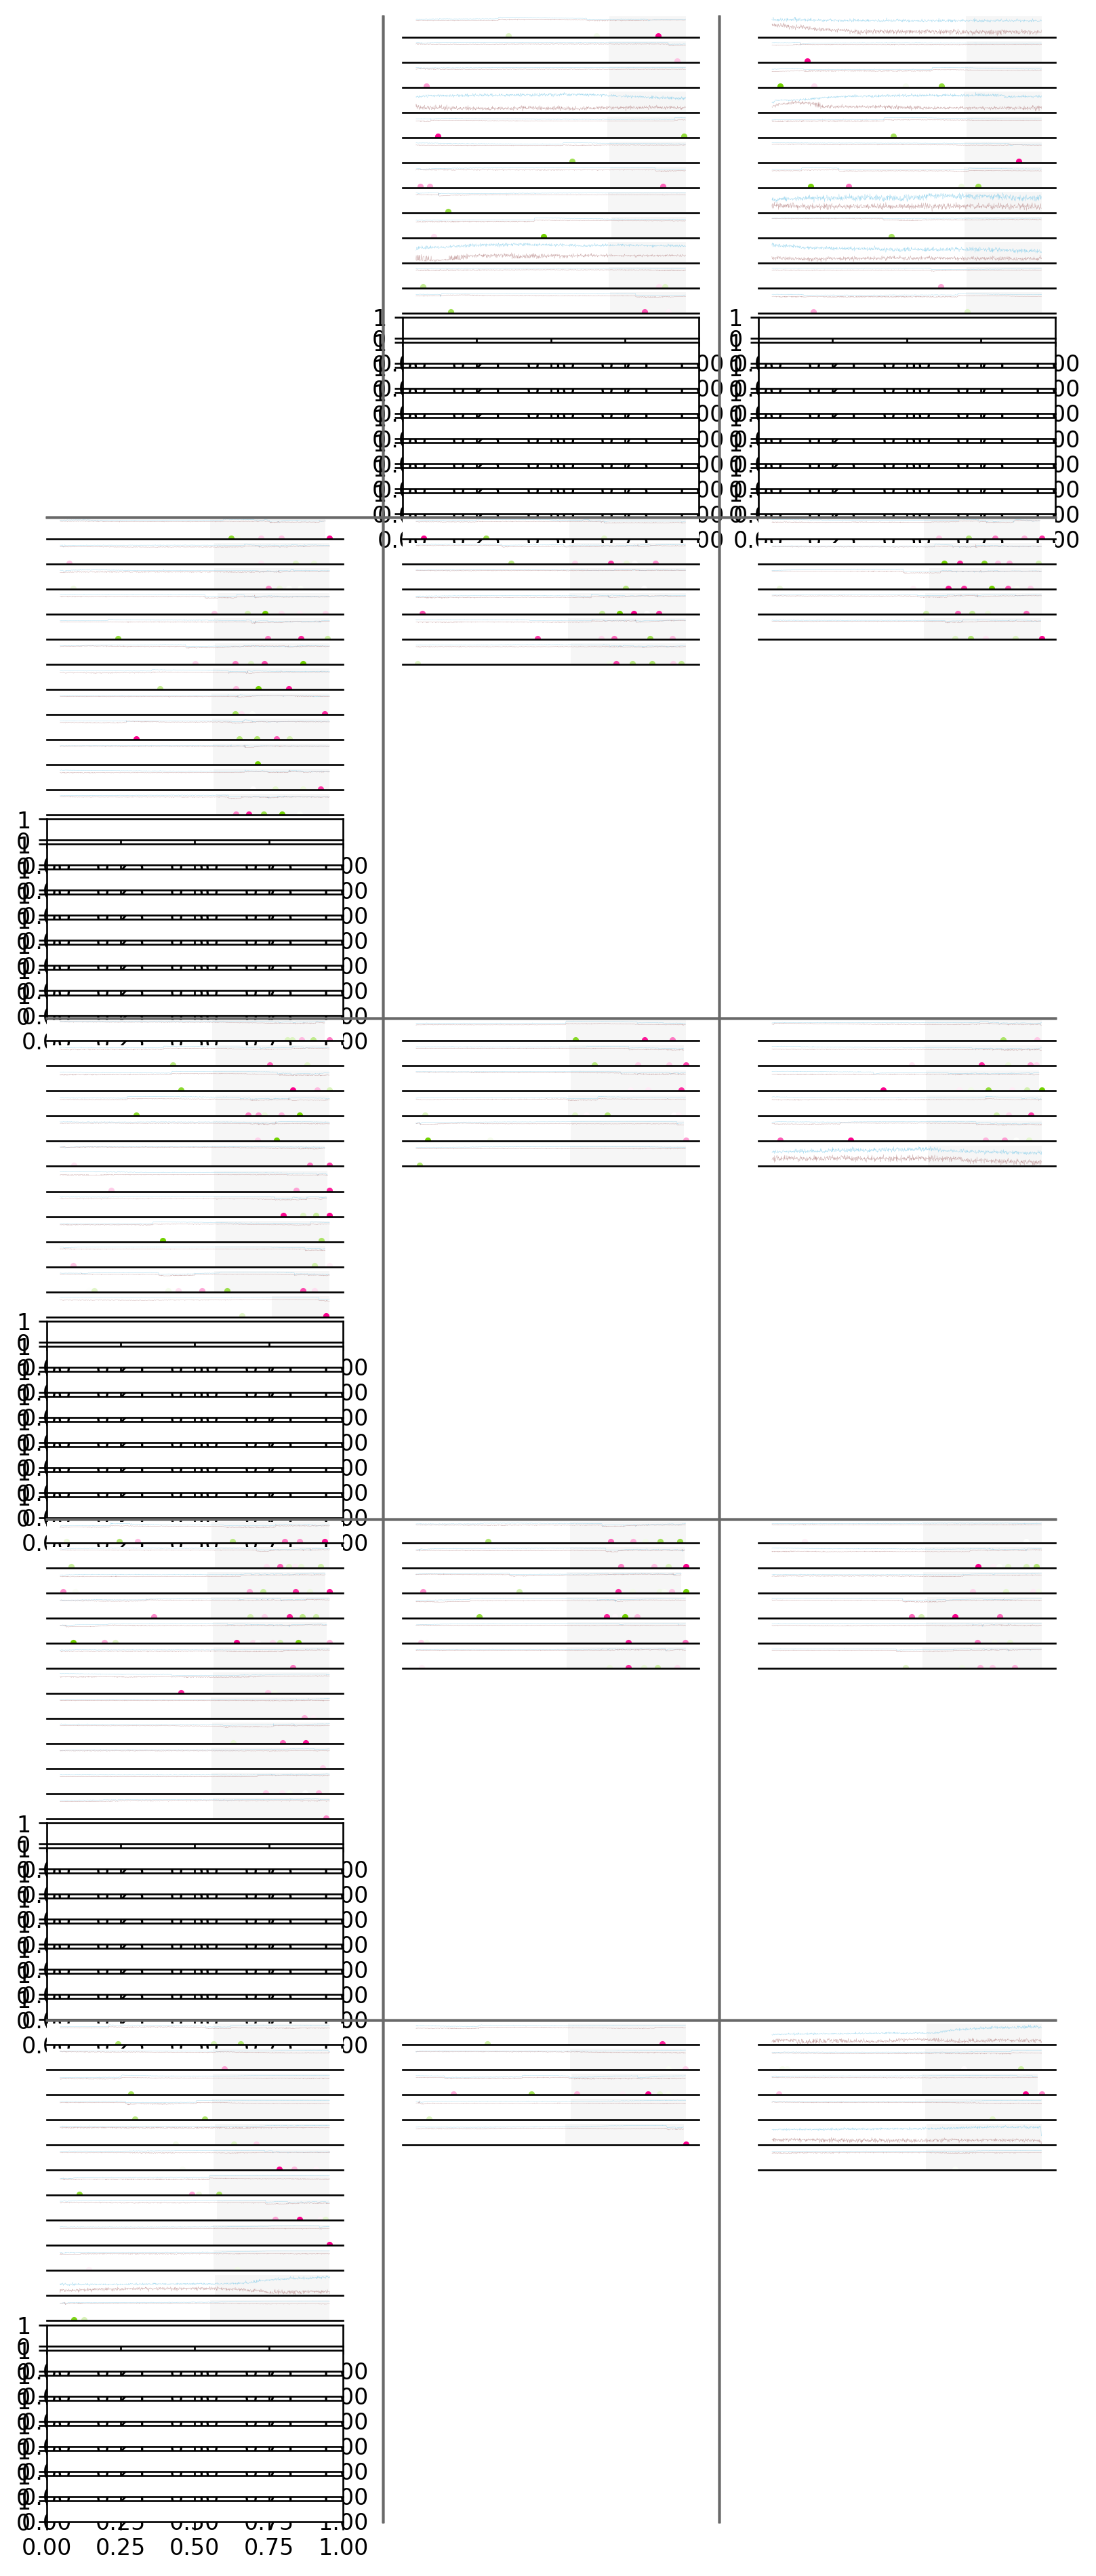

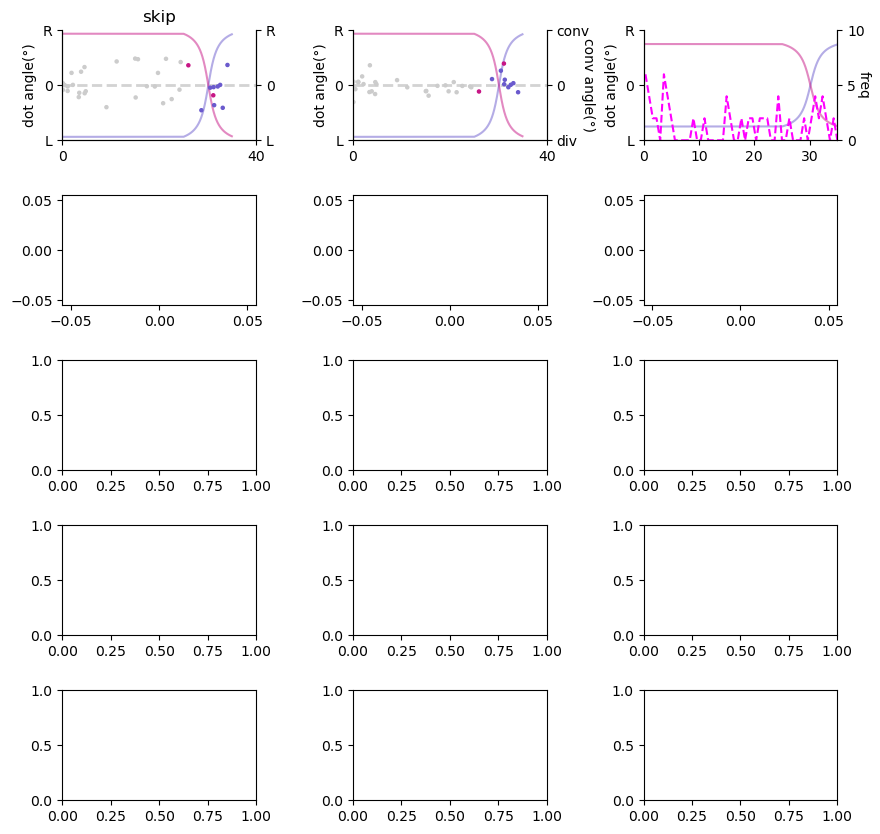

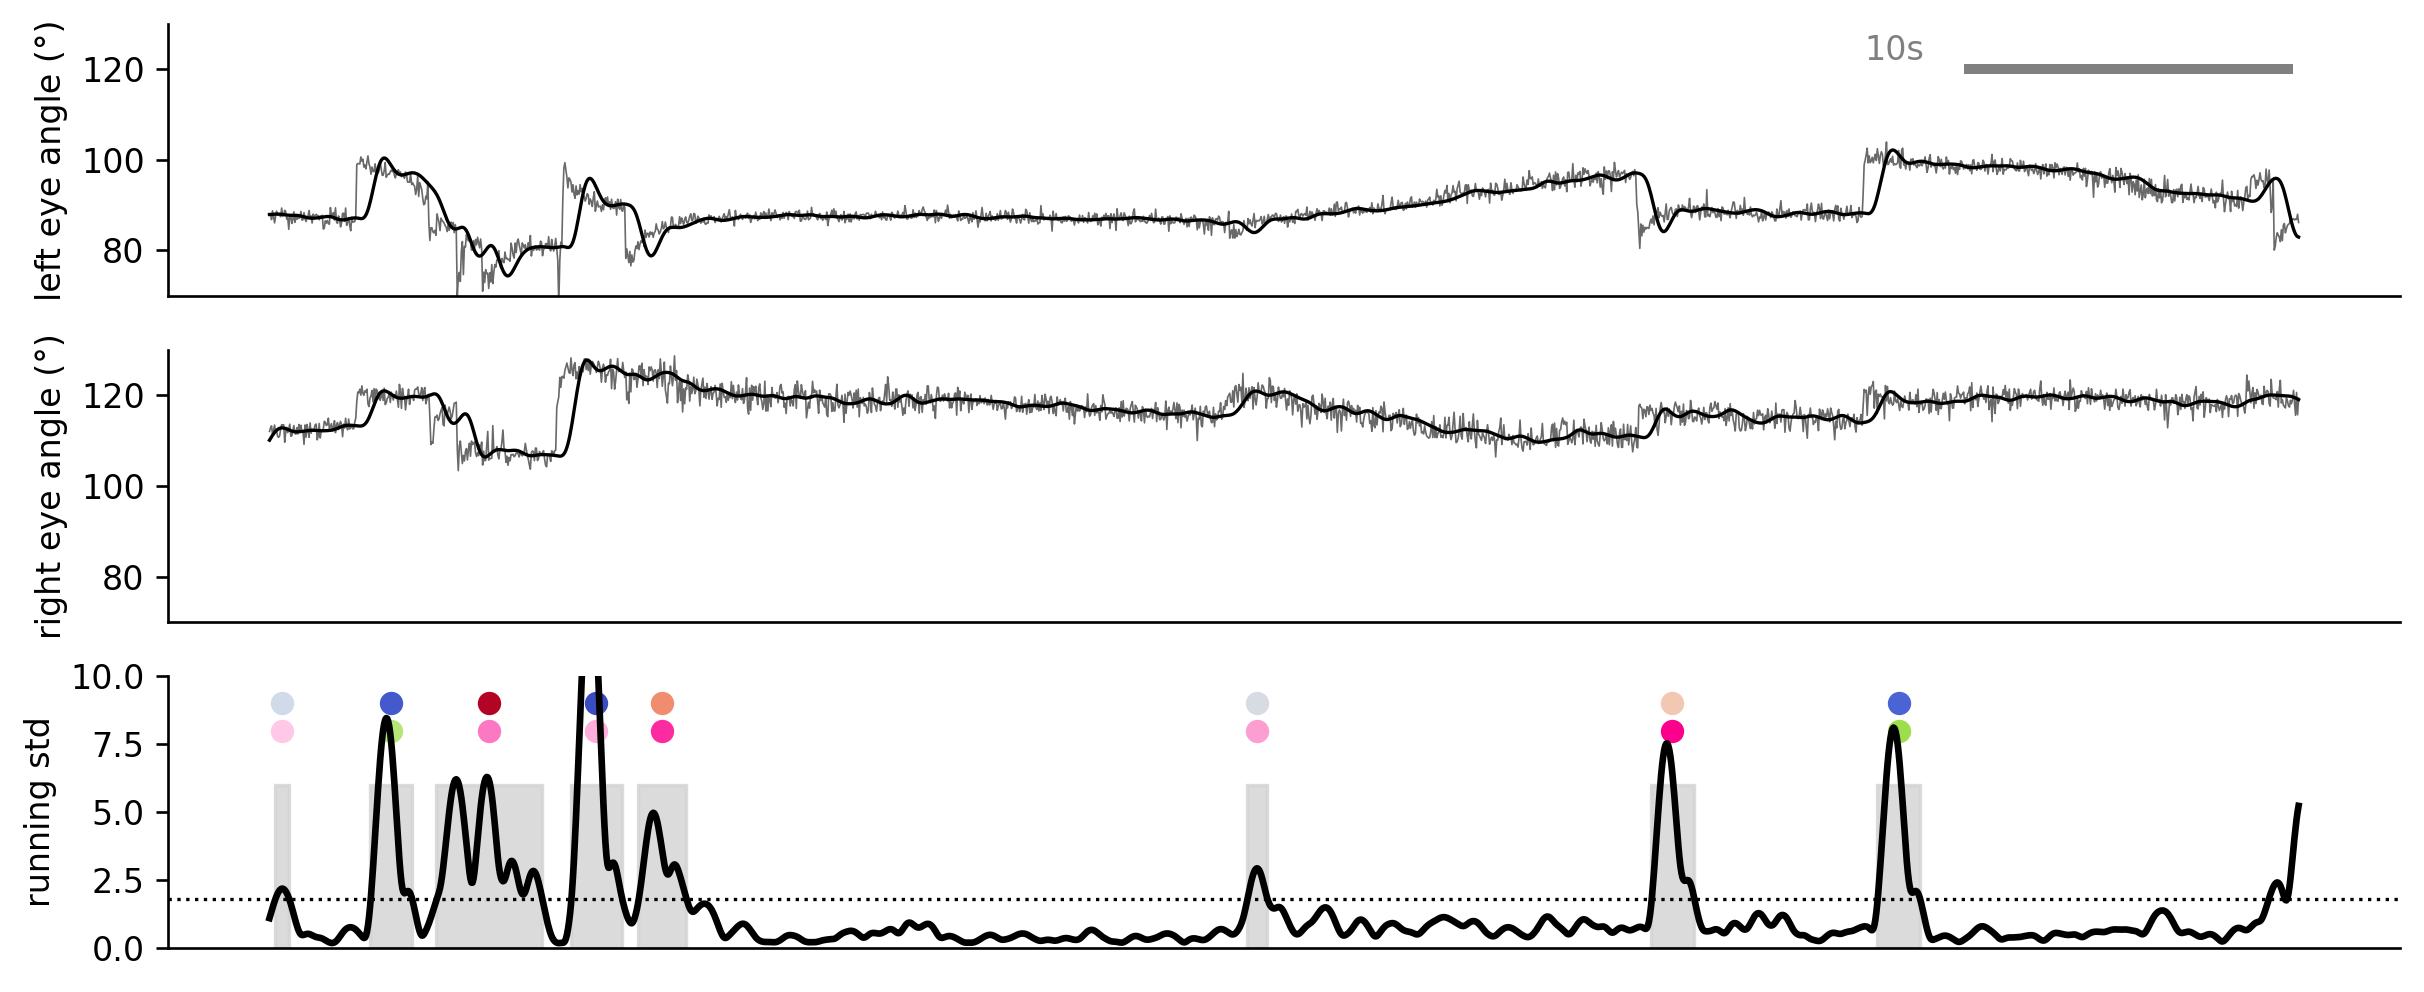

In [44]:
fig = bhfd.saccade_finder(fish, time_window_s =1, min_interval_s = 0.1, min_saccade_s = 0.1, startframe = 16918, endframe = 18918,
               lowpass = True, std_scale =.5
                          )
fish.saccade_df.to_csv(fish.path + 'Eye//eye_saccade_df.csv')
plt.show()
plt.close()
fig.savefig(fish.path + '//Graphs//saccade_example.png')

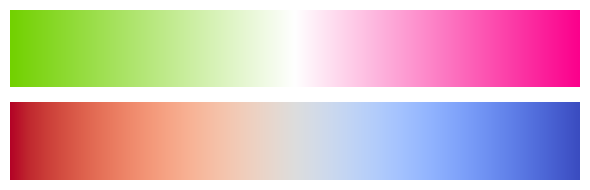

In [45]:
#plot associated cmaps
cmaps = [cmap_conv, 'coolwarm_r']
fig, axes = plt.subplots(len(cmaps), 1, figsize=(6, 2))
for ax, name in zip(axes, cmaps):
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect="auto", cmap=name)
    ax.axis("off")

plt.tight_layout()
plt.show()
plt.close()

C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:204: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)


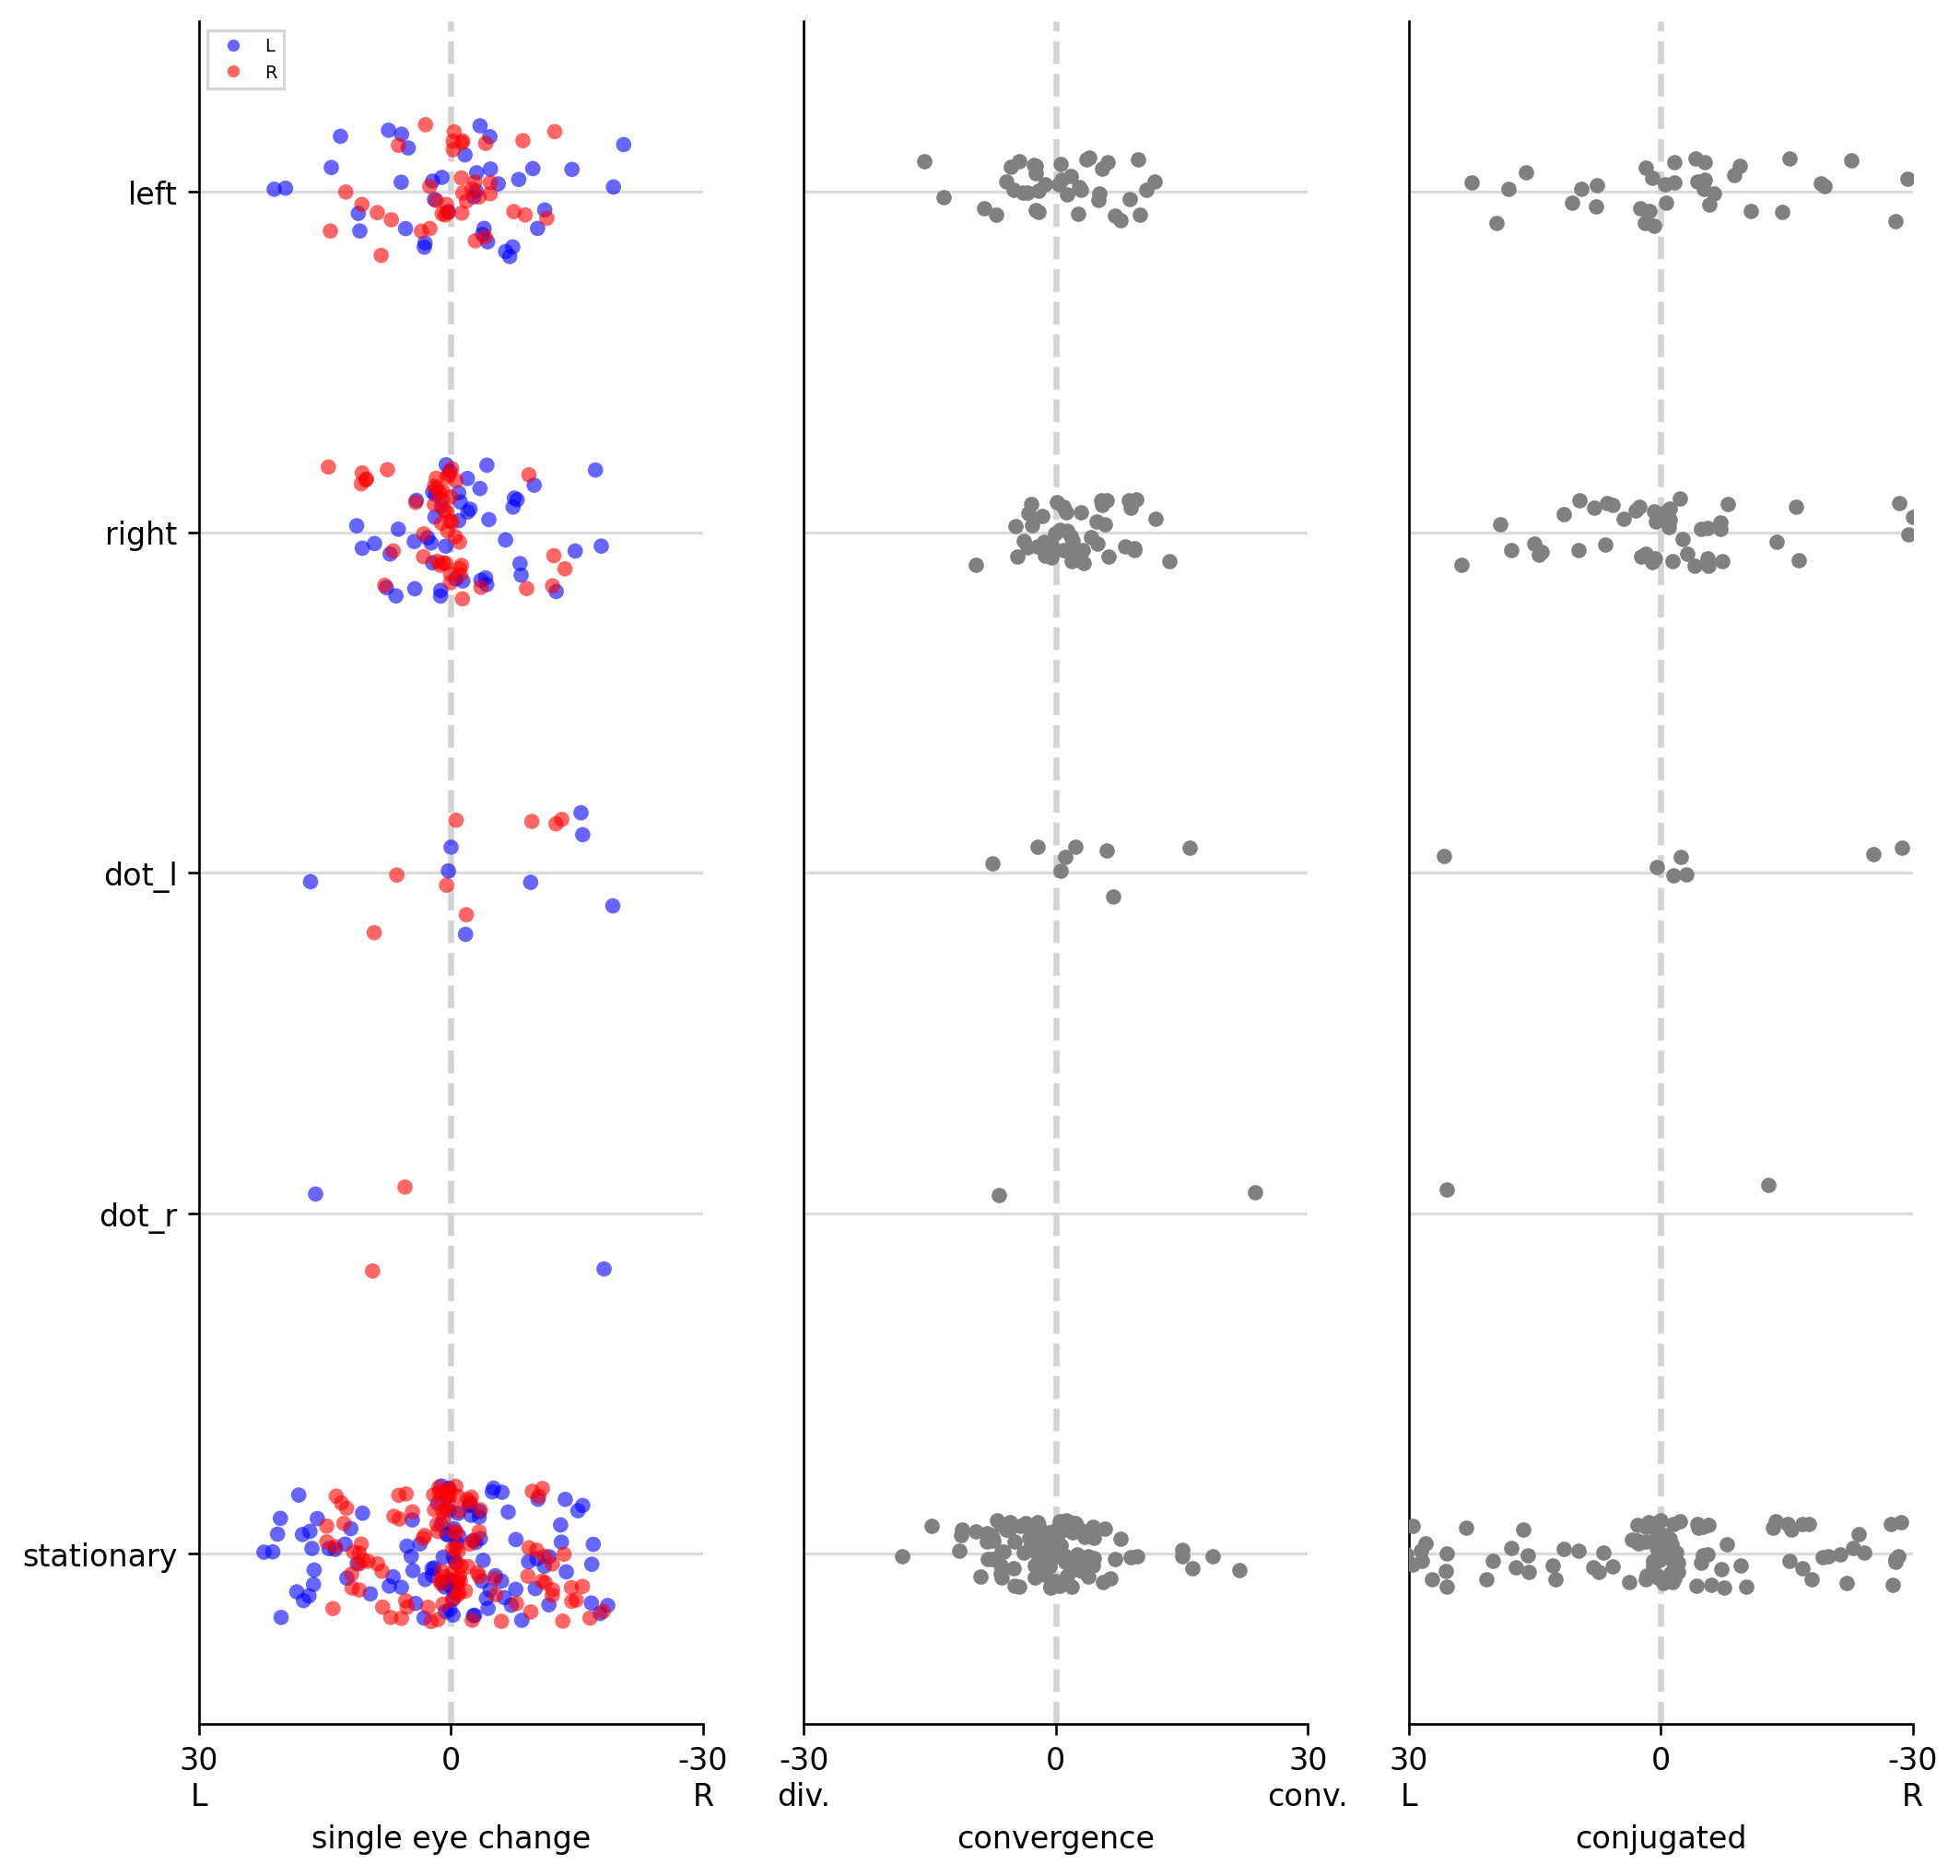

In [46]:
stim_order = ['left', 'right', 'dot_l', 'dot_r', 'stationary']

fig = bhfd.plot_saccade_distribution(fish, stimorder = stim_order)
fig.savefig(fish.path + '//Graphs//saccade_stats.png')
plt.show()
plt.close()

In [40]:
stim_matrix =  np.array([['skip', 'dot_l', 'dot_r'],
                        ['forward', "['dot_l', 'forward']", "['dot_r', 'forward']"],
                        ['left', "['dot_l', 'left']", "['dot_r', 'left']"],
                        ['right', "['dot_l', 'right']", "['dot_r', 'right']"],
                        ['backward', "['dot_l', 'backward']", "['dot_r', 'backward']"]])
fig = bhfd.plot_all_saccades(fish,stim_matrix)
fig.savefig(fish.path + '//Graphs//saccade_all.png')

In [35]:
plt.close()

plotting 2p setup dot position
plotting 2p setup dot position


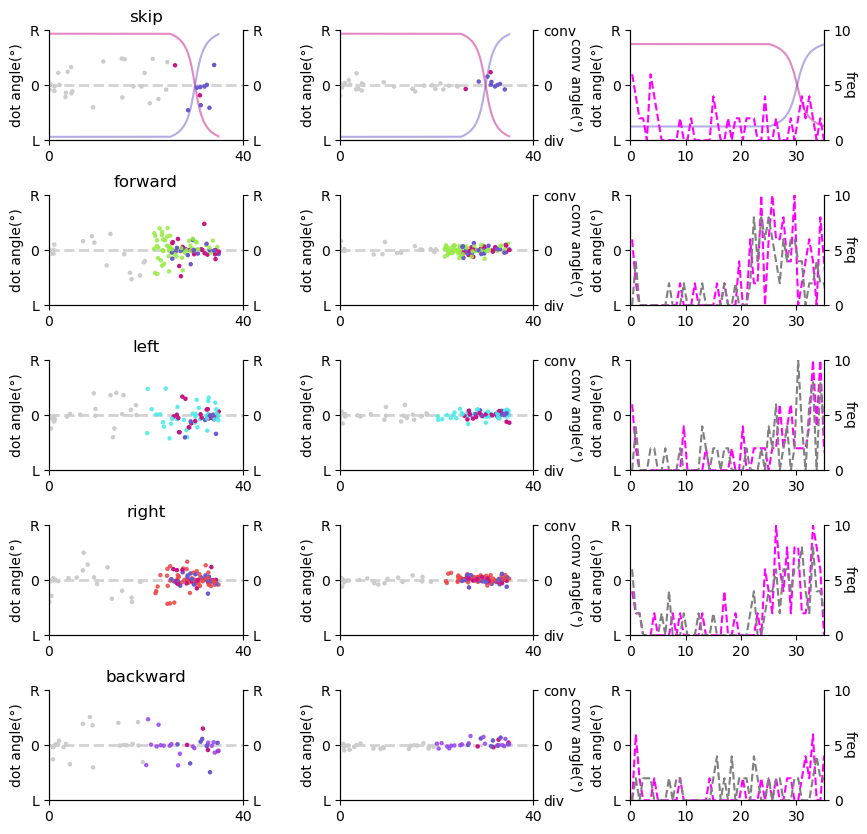

In [49]:
def plot_individual_saccade_overtime(all_df, stim_matrix, stims):
    all_df.eye_realstimuli = [str(s) for s in all_df.eye_realstimuli]
    all_df.eye_stimuli = [str(s) for s in all_df.eye_stimuli]
    fig, ax = plt.subplots(len(stim_matrix), 3, figsize = (10, 10), gridspec_kw = {'wspace': 0.5, 'hspace': 0.5})
    for n, row in enumerate(stim_matrix):
        for stim in row:
            if stim =='skip' or stim == 'pause' or '[' in stim:
                continue
            if 'dot_l' in stim:
                stimc = 'slateblue'
            elif 'dot_r' in stim:
                stimc = 'mediumvioletred'
            elif 'left' in stim:
                stimc = 'blue'
            elif 'right' in stim:
                stimc = 'red'
            # elif 'pause' in stim:
            #     stimc = 'grey'
            stim_df = stims[stims['stim_name'] == stim].iloc[0]
            _, stim_loc_timescale, stim_loc_scale, center_time= utils.get_dot_pos(stim_df, canvas_size=1024)
            #because it's behavior rig, stim_loc_scale got changed
            #stim_loc_scale = np.subtract(0, stim_loc_scale)
            [ax[n, col].plot(stim_loc_timescale, stim_loc_scale, c = stimc, alpha = 0.5, zorder = 0) for col in range(3)]
        row_saccade_df = all_df.loc[all_df['eye_stimuli'].isin(row)]
        stim_c = ['grey' if 'pause' in s else 'slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else utils.stim_colors[s] for s in row_saccade_df.eye_realstimuli]#['slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else 'grey' for s in row_saccade_df.eye_realstimuli]
        ax_conj = ax[n,0].twinx()
        ax_conj.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conj_change, color = stim_c, s = 5, zorder = 2)
        ax_conv = ax[n,1].twinx()
        ax_conv.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conv_change, color = stim_c, s = 5, zorder = 2)
        ax[n, 0].set_title(f"{row[0].split('_')[-1]}")
        ax[n, 0].set_ylabel('dot angle(°)')
        ax_conj.yaxis.set_label_position("right")
        ax[n, 1].set_ylabel('dot angle(°)')
        ax_conv.yaxis.set_label_position("right")
        ax_conv.set_ylabel('conv angle(°)', rotation = 270)
        #[ax[n, col].axvline(center_time, linewidth = 2, color = 'lightgrey', linestyle = '--', zorder = -1) for col in range(2)]
        [ax[n, col].axhline(0, linewidth = 2, color = 'lightgrey', linestyle = '--', zorder = -1)  for col in range(2)]
        [ax[n, col].set_xlim([0, 40]) for col in range(2)]
        [ax[n, col].set_xticks([0, 40]) for col in range(2)]
        [ax[n, col].set_ylim([-80, 80]) for col in range(2)]
        [ax[n, col].set_yticks([-80,0, 80]) for col in range(2)]
        [ax[n, col].set_yticklabels(['L', 0, 'R']) for col in range(2)]
        ax_conj.set_ylim([-70, 70])
        ax_conj.set_yticks([-70,0, 70])
        ax_conj.set_yticklabels(['L', 0, 'R'])
        lim = 100
        ax_conv.set_ylim([-lim, lim])
        ax_conv.set_yticks([-lim,0, lim])
        ax_conv.set_yticklabels(['div', 0, 'conv'])
        [ax[n, col].spines[['top']].set_visible(False) for col in range(2)]
        ax_conv.spines[['top']].set_visible(False)
        ax_conj.spines[['top']].set_visible(False)

        #plot frequency over time
        ax_freq = ax[n,2].twinx()
        dot_stims = [s for s in row if 'dot' in str(s)]
        nondot_stims = [s for s in row if 'dot' not in s]
        row_saccade_dot_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(dot_stims)]
        row_saccade_nondot_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(nondot_stims)]
        if len(row_saccade_dot_df) > 0:
            freq, bin_loc = np.histogram(row_saccade_dot_df.eye_fromstart_s, bins = 60, range = [0, 40])
            bin_center = (bin_loc[:-1] + bin_loc[1:]) / 2
            ax_freq.plot(bin_center, np.multiply(freq, 2), color = 'magenta', linestyle = '--', zorder = 1)
        if len(row_saccade_nondot_df) > 0:
            freq, bin_loc = np.histogram(row_saccade_nondot_df.eye_fromstart_s, bins = 60, range = [0, 40])
            bin_center = (bin_loc[:-1] + bin_loc[1:]) / 2
            ax_freq.plot(bin_center, np.multiply(freq, 2), color = 'grey', linestyle = '--', zorder = 1)
        ax_freq.spines[['top']].set_visible(False)
        ax[n,2].spines[['top']].set_visible(False)
        ax[n, 2].set_xlim([0, 35])
        ax_freq.set_xlim([0, 35])
        ax[n, 2].set_ylim([-100, 10])
        ax[n, 2].set_yticks([-100,0, 100])
        ax[n, 2].set_yticklabels(['L', 0, 'R'])
        ax_freq.set_ylim([0, 10])
        ax_freq.set_yticks([0, 5, 10])
        ax[n, 2].set_ylabel('dot angle(°)')
        ax_freq.set_ylabel('freq', rotation = -90)
    return fig

fig = plot_individual_saccade_overtime(fish.saccade_df, stim_matrix, fish.stimulus_df)
fig.savefig(fish.path + '//Graphs//saccade_acrosstime_Casper.png')
plt.show()
plt.close()

__combine all fish__

In [22]:
for fish in [ r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish14//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish3//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish4//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish5//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish6//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish7//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish8//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish9//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish10//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish11//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish12//",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish13//",]:
    fishpath = fish + '//'
    #if imaging fish
    fish = Gafftopsail(fishpath, sequence  = 5, filelist = ['stimulus', 'eye'])
    #if behavior rig fish
    #fish = Coelacanth(fishpath, filelist=['taileye', 'stimulus'])
    if type(fish) == Gafftopsail:
        pass
    elif type(fish) == Coelacanth:
        fish.eye_df = fish.taileye_df
        fish.eye_df.columns = ['f0_x', 'f0_vx', 'f0_y', 'f0_vy', 'f0_theta', 'f0_vtheta',
                               'f0_theta_00', 'f0_theta_01', 'f0_theta_02', 'f0_theta_03',
                               'f0_theta_04', 'f0_theta_05', 'f0_theta_06', 'f0_theta_07',
                               'f0_theta_08', 'f0_theta_09', 'f0_theta_10', 'f0_theta_11',
                               'f0_pos_x_e0', 'f0_pos_y_e0', 'f0_dim_x_e0', 'f0_dim_y_e0', 'th_e0',
                               'f0_pos_x_e1', 'f0_pos_y_e1', 'f0_dim_x_e1', 'f0_dim_y_e1', 'th_e1',
                               'biggest_area', 't', 'real_time', 'real_time_s']
    fig = bhfd.saccade_finder(fish, time_window_s=1, min_interval_s=0.1, min_saccade_s=0.1, startframe=36918,
                              endframe=56918,
                              lowpass=True, std_scale=1)
    fish.saccade_df.to_csv(fish.path + 'Eye//eye_saccade_df.csv')
    fig.savefig(fish.path + '//Graphs//saccade_example.png')
    plt.close(fig)
    #plot associated cmaps
    fig = bhfd.plot_saccade_distribution(fish,
                                         stimorder= stim_order)
    fig.savefig(fish.path + '//Graphs//saccade_stats.png')
    plt.close(fig)
    fig = bhfd.plot_all_saccades(fish, stim_matrix)
    fig.savefig(fish.path + '//Graphs//saccade_all.png')
    plt.close(fig)

C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:202: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:202: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:202: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:202: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat